In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class ToyConfig:
    vocab_size = 65       # Character-level / small vocabulary
    seq_len = 32          # Stream / context window length L
    d_model = 128         # Hidden dimension
    n_layer = 4           # Number of transformer blocks
    n_head = 4            # Multi-head attention heads
    d_ff = 512            # FFN intermediate dimension (4 * d_model)

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.d_model = config.d_model
        self.head_dim = config.d_model // config.n_head

        self.w_q = nn.Linear(config.d_model, config.d_model, bias=False)
        self.w_k = nn.Linear(config.d_model, config.d_model, bias=False)
        self.w_v = nn.Linear(config.d_model, config.d_model, bias=False)
        self.w_o = nn.Linear(config.d_model, config.d_model, bias=False)

    def forward(self, x, attn_mask=None):
        B, L, D = x.shape

        # Project and split heads: (B, L, D) -> (B, H, L, head_dim)
        q = self.w_q(x).view(B, L, self.n_head, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(B, L, self.n_head, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(B, L, self.n_head, self.head_dim).transpose(1, 2)

        # Dot-product scores
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Apply standard Causal Mask
        causal_mask = torch.tril(torch.ones(L, L, device=x.device)).view(1, 1, L, L)
        scores = scores.masked_fill(causal_mask == 0, float('-inf'))

        # Apply Custom External Mask (e.g. Attention Pad or Document Boundary Mask)
        if attn_mask is not None:
            # attn_mask shape: (B, 1, L, L) or broadcastable
            scores = scores.masked_fill(attn_mask == 0, float('-inf'))

        probs = F.softmax(scores, dim=-1)
        out = probs @ v # (B, H, L, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, L, D)
        return self.w_o(out)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.d_model)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.d_model)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff, bias=False),
            nn.GELU(),
            nn.Linear(config.d_ff, config.d_model, bias=False)
        )

    def forward(self, x, attn_mask=None):
        x = x + self.attn(self.ln1(x), attn_mask=attn_mask)
        x = x + self.ffn(self.ln2(x))
        return x

# --- Full Toy GPT Model ---
class ToyGPT(nn.Module):
    def __init__(self, config, tie_weights=False):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_emb = nn.Embedding(config.seq_len, config.d_model)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.d_model)
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)

        if tie_weights:
            self.lm_head.weight = self.tok_emb.weight

    def forward(self, tokens, attn_mask=None):
        B, L = tokens.shape
        pos = torch.arange(0, L, device=tokens.device).unsqueeze(0)
        x = self.tok_emb(tokens) + self.pos_emb(pos)

        for block in self.blocks:
            x = block(x, attn_mask=attn_mask)

        hidden = self.ln_f(x)
        return hidden

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config = ToyConfig()
model = ToyGPT(config, tie_weights=False).to(device)

In [ ]:
print("=" * 70)
print("PART 1 DELIVERABLE 1: Tensor Shapes & One-Line Dimension Descriptions")
print("=" * 70)

PART 1 DELIVERABLE 1: Tensor Shapes & One-Line Dimension Descriptions


# Dummy batch: Batch size B=2, Sequence length L=32

In [ ]:
tokens = torch.randint(1, config.vocab_size, (2, config.seq_len)).to(device)

hidden = model(tokens)
logits = model.lm_head(hidden)

In [ ]:
logits_shifted = logits[:, :-1, :].contiguous().view(-1, config.vocab_size)
targets_shifted = tokens[:, 1:].contiguous().view(-1)
loss = F.cross_entropy(logits_shifted, targets_shifted)

print(f"tokens shape:         {list(tokens.shape)}         -> [B, L]: Batch size, Sequence Length")
print(f"hidden shape:         {list(hidden.shape)}     -> [B, L, d_model]: Batch size, Sequence Length, Hidden Dimension")
print(f"logits shape:         {list(logits.shape)}     -> [B, L, V]: Batch size, Sequence Length, Vocabulary Size")
print(f"logits_shifted shape: {list(logits_shifted.shape)}     -> [(B * (L-1)), V]: Flattened time-steps, Vocabulary Size")
print(f"targets_shifted shape:{list(targets_shifted.shape)}       -> [(B * (L-1))]: Flattened target token IDs")
print(f"loss shape:           {list(loss.shape)}             -> []: Scalar loss value")


print("\n" + "=" * 70)
print("PART 1 DELIVERABLE 2: Verify the Shift by Printing String Tokens Side-by-Side")
print("=" * 70)

tokens shape:         [2, 32]         -> [B, L]: Batch size, Sequence Length
hidden shape:         [2, 32, 128]     -> [B, L, d_model]: Batch size, Sequence Length, Hidden Dimension
logits shape:         [2, 32, 65]     -> [B, L, V]: Batch size, Sequence Length, Vocabulary Size
logits_shifted shape: [62, 65]     -> [(B * (L-1)), V]: Flattened time-steps, Vocabulary Size
targets_shifted shape:[62]       -> [(B * (L-1))]: Flattened target token IDs
loss shape:           []             -> []: Scalar loss value

PART 1 DELIVERABLE 2: Verify the Shift by Printing String Tokens Side-by-Side


In [ ]:
# Simple character mapping for visualization
chars = [chr(i + 33) for i in range(config.vocab_size)]
char_to_id = {ch: i for i, ch in enumerate(chars)}
id_to_char = {i: ch for i, ch in enumerate(chars)}

sample_str = "the_quick_brown_fox_jumps_over!" # Exactly 31 chars -> 32 tokens with alignment
sample_ids = torch.tensor([[char_to_id.get(c, 0) for c in sample_str]], device=device)

input_seq = sample_ids[:, :-1]
target_seq = sample_ids[:, 1:]

input_chars = [id_to_char[idx.item()] for idx in input_seq[0]]
target_chars = [id_to_char[idx.item()] for idx in target_seq[0]]

print("Step-by-Step Alignment Verification:")
for t in range(min(10, len(input_chars))): # Print first 10 steps
    print(f"  Position t={t:2d} | Input: '{input_chars[t]}'  ---> Predicts Target: '{target_chars[t]}'")


print("\n" + "=" * 70)
print("PART 1 DELIVERABLE 3: Mask Padding & Confirm Token Count Change")
print("=" * 70)

PAD_ID = 0
padded_tokens = tokens.clone()
padded_tokens[:, 20:] = PAD_ID  # Set last 12 tokens of every sequence to PAD

# Shifted targets
targets_with_pad = padded_tokens[:, 1:].contiguous().view(-1)

Step-by-Step Alignment Verification:
  Position t= 0 | Input: '!'  ---> Predicts Target: '!'
  Position t= 1 | Input: '!'  ---> Predicts Target: '!'
  Position t= 2 | Input: '!'  ---> Predicts Target: '_'
  Position t= 3 | Input: '_'  ---> Predicts Target: '!'
  Position t= 4 | Input: '!'  ---> Predicts Target: '!'
  Position t= 5 | Input: '!'  ---> Predicts Target: '!'
  Position t= 6 | Input: '!'  ---> Predicts Target: '!'
  Position t= 7 | Input: '!'  ---> Predicts Target: '!'
  Position t= 8 | Input: '!'  ---> Predicts Target: '_'
  Position t= 9 | Input: '_'  ---> Predicts Target: '!'

PART 1 DELIVERABLE 3: Mask Padding & Confirm Token Count Change


In [ ]:
# Unmasked count
total_tokens_unmasked = targets_with_pad.numel()

# Masked count using ignore_index logic
active_tokens_masked = (targets_with_pad != PAD_ID).sum().item()

print(f"Total tokens before padding mask: {total_tokens_unmasked}")
print(f"Active contributing tokens after padding mask (ignore_index=0): {active_tokens_masked}")


print("\n" + "=" * 70)
print("PART 1 DELIVERABLE 4: Packed Documents & Boundary Mask Loss Comparison")
print("=" * 70)

Total tokens before padding mask: 62
Active contributing tokens after padding mask (ignore_index=0): 38

PART 1 DELIVERABLE 4: Packed Documents & Boundary Mask Loss Comparison


In [ ]:
# Create sequence packing Doc A (16 tokens) + Doc B (16 tokens)
doc_a = torch.randint(1, config.vocab_size, (1, 16)).to(device)
doc_b = torch.randint(1, config.vocab_size, (1, 16)).to(device)
packed_seq = torch.cat([doc_a, doc_b], dim=1) # (1, 32)

# Unmasked Loss (Doc B token 1 learns from Doc A last token)
h_unmasked = model(packed_seq)
l_unmasked = model.lm_head(h_unmasked)
loss_unmasked = F.cross_entropy(l_unmasked[:, :-1].view(-1, config.vocab_size), packed_seq[:, 1:].view(-1))

# Block-Causal Masking (Isolate Attention between Doc A and Doc B)
block_mask = torch.ones(1, 1, 32, 32, device=device)
block_mask[:, :, :16, 16:] = 0 # Prevent Doc A from seeing Doc B
block_mask[:, :, 16:, :16] = 0 # Prevent Doc B from seeing Doc A

h_masked = model(packed_seq, attn_mask=block_mask)
l_masked = model.lm_head(h_masked)

# Mask loss specifically at transition index 15 (Doc A -> Doc B shift point)
target_packed = packed_seq[:, 1:].clone()
target_packed[:, 15] = -100 # PyTorch default ignore_index
loss_masked = F.cross_entropy(l_masked[:, :-1].view(-1, config.vocab_size), target_packed.view(-1), ignore_index=-100)

print(f"Loss WITHOUT boundary masking: {loss_unmasked.item():.4f}")
print(f"Loss WITH boundary masking:    {loss_masked.item():.4f}")
print("Explanation: Boundary masking prevents cross-document attention leakage and removes the fake loss penalty of predicting Document B's start token from Document A's end token.")


print("\n" + "=" * 70)
print("PART 1 DELIVERABLE 5: Untrained Model Perplexity Verification")
print("=" * 70)

Loss WITHOUT boundary masking: 4.3504
Loss WITH boundary masking:    4.3536
Explanation: Boundary masking prevents cross-document attention leakage and removes the fake loss penalty of predicting Document B's start token from Document A's end token.

PART 1 DELIVERABLE 5: Untrained Model Perplexity Verification


In [ ]:
untrained_model = ToyGPT(config).to(device)
with torch.no_grad():
    h_init = untrained_model(tokens)
    l_init = untrained_model.lm_head(h_init)
    init_loss = F.cross_entropy(l_init[:, :-1].contiguous().view(-1, config.vocab_size), tokens[:, 1:].contiguous().view(-1))
    ppl = math.exp(init_loss.item())

print(f"Vocabulary Size (V): {config.vocab_size}")
print(f"Initial Cross-Entropy Loss: {init_loss.item():.4f}  (Theoretical ln(V) = {math.log(config.vocab_size):.4f})")
print(f"Untrained Model Perplexity: {ppl:.2f}  (Expected ~{config.vocab_size})")


print("\n" + "=" * 70)
print("PART 1 DELIVERABLE 6: Compare Tied vs. Untied Parameter Counts")
print("=" * 70)

Vocabulary Size (V): 65
Initial Cross-Entropy Loss: 4.3478  (Theoretical ln(V) = 4.1744)
Untrained Model Perplexity: 77.31  (Expected ~65)

PART 1 DELIVERABLE 6: Compare Tied vs. Untied Parameter Counts


In [ ]:
untied_model = ToyGPT(config, tie_weights=False)
tied_model = ToyGPT(config, tie_weights=True)

untied_params = sum(p.numel() for p in untied_model.parameters() if p.requires_grad)
tied_params = sum(p.numel() for p in tied_model.parameters() if p.requires_grad)

print(f"Untied Head Total Parameters: {untied_params:,}")
print(f"Tied Head Total Parameters:   {tied_params:,}")
print(f"Parameter Difference:         {untied_params - tied_params:,} (Exactly V * d_model = {config.vocab_size * config.d_model:,})")


print("\n" + "=" * 70)
print("PART 1 DELIVERABLE 7: Peak Memory (Standard vs. Chunked Cross-Entropy)")
print("=" * 70)

def chunked_cross_entropy(hidden, lm_head, targets, chunk_size=4):
    """
    Computes cross-entropy loss by chunking hidden state along time dimension L.
    """
    B, L, D = hidden.shape
    V = lm_head.weight.shape[0]

    # Flatten targets
    targets_flat = targets.contiguous().view(-1)
    total_loss = 0.0
    total_count = 0

    for i in range(0, L, chunk_size):
        # Slice hidden chunk: (B, L_chunk, D)
        hidden_chunk = hidden[:, i:i+chunk_size, :]
        targets_chunk = targets[:, i:i+chunk_size].contiguous().view(-1)

        # Project only this slice to logits
        logits_chunk = lm_head(hidden_chunk).view(-1, V)

        # Calculate unreduced loss
        loss_chunk = F.cross_entropy(logits_chunk, targets_chunk, reduction='sum')
        total_loss += loss_chunk
        total_count += (targets_chunk != -100).sum()

    return total_loss / total_count

if torch.cuda.is_available():
    # Use larger dimensions specifically for the VRAM stress test so logits dominate memory
    test_B, test_L, test_V, test_D = 4, 1024, 32000, 512

    # Test hidden states and test LM head weight matrix
    test_hidden = torch.randn(test_B, test_L, test_D, device=device, requires_grad=True)
    test_head = nn.Linear(test_D, test_V, bias=False).to(device)
    test_targets = torch.randint(0, test_V, (test_B, test_L), device=device)

    # 1. Standard Loss Memory Test
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    logits_std = test_head(test_hidden)
    loss_std = F.cross_entropy(
        logits_std[:, :-1].contiguous().view(-1, test_V),
        test_targets[:, 1:].contiguous().view(-1)
    )
    loss_std.backward()

    std_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) # MB

    # 2. Chunked Loss Memory Test
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Reset gradients
    if test_hidden.grad is not None: test_hidden.grad.zero_()
    test_head.zero_grad()

    loss_chunked = chunked_cross_entropy(
        test_hidden[:, :-1],
        test_head,
        test_targets[:, 1:],
        chunk_size=32
    )
    loss_chunked.backward()

    chunked_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) # MB
    ratio = std_memory / chunked_memory if chunked_memory > 0 else 1.0

    print(f"Standard Cross-Entropy Peak Memory: {std_memory:.2f} MB")
    print(f"Chunked Cross-Entropy Peak Memory:  {chunked_memory:.2f} MB")
    print(f"Memory Reduction Ratio:             {ratio:.2f}x")
else:
    print("CUDA not detected. Run this section on Google Colab (T4 GPU) to record GPU peak memory MB numbers.")

Untied Head Total Parameters: 809,472
Tied Head Total Parameters:   801,152
Parameter Difference:         8,320 (Exactly V * d_model = 8,320)

PART 1 DELIVERABLE 7: Peak Memory (Standard vs. Chunked Cross-Entropy)
Standard Cross-Entropy Peak Memory: 2089.39 MB
Chunked Cross-Entropy Peak Memory:  1277.55 MB
Memory Reduction Ratio:             1.64x


In [ ]:

print("=" * 70)
print("PART 2: Dual Output Head (Predicting t+1 and t+2)")
print("=" * 70)

class DualHeadToyGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_emb = nn.Embedding(config.seq_len, config.d_model)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.d_model)

        # Head 1 predicts next token (t+1)
        self.head_t1 = nn.Linear(config.d_model, config.vocab_size, bias=False)
        # Head 2 predicts skip token (t+2)
        self.head_t2 = nn.Linear(config.d_model, config.vocab_size, bias=False)

    def forward(self, tokens):
        B, L = tokens.shape
        pos = torch.arange(0, L, device=tokens.device).unsqueeze(0)
        x = self.tok_emb(tokens) + self.pos_emb(pos)

        for block in self.blocks:
            x = block(x)

        hidden = self.ln_f(x)
        return hidden

# Instantiate Dual-Head Model and Optimizer
dual_model = DualHeadToyGPT(config).to(device)
optimizer = torch.optim.AdamW(dual_model.parameters(), lr=1e-3)

# Training loop simulation over 50 steps
print(f"{'Step':^6} | {'Loss_1 (t+1)':^14} | {'Loss_2 (t+2)':^14} | {'Total Loss':^12}")
print("-" * 52)

for step in range(51):
    dummy_input = torch.randint(1, config.vocab_size, (4, config.seq_len)).to(device)

    hidden = dual_model(dummy_input)

    # Head 1 predictions: inputs [:, :-2] predict targets at t+1 [:, 1:-1]
    logits_t1 = dual_model.head_t1(hidden[:, :-2])
    targets_t1 = dummy_input[:, 1:-1]
    loss_1 = F.cross_entropy(
        logits_t1.contiguous().view(-1, config.vocab_size),
        targets_t1.contiguous().view(-1)
    )

    # Head 2 predictions: inputs [:, :-2] predict targets at t+2 [:, 2:]
    logits_t2 = dual_model.head_t2(hidden[:, :-2])
    targets_t2 = dummy_input[:, 2:]
    loss_2 = F.cross_entropy(
        logits_t2.contiguous().view(-1, config.vocab_size),
        targets_t2.contiguous().view(-1)
    )

    total_loss = loss_1 + loss_2

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 10 == 0:
        print(f"{step:6d} | {loss_1.item():14.4f} | {loss_2.item():14.4f} | {total_loss.item():12.4f}")

PART 2: Dual Output Head (Predicting t+1 and t+2)
 Step  |  Loss_1 (t+1)  |  Loss_2 (t+2)  |  Total Loss 
----------------------------------------------------
     0 |         4.2993 |         4.4283 |       8.7276
    10 |         4.3382 |         4.3058 |       8.6440
    20 |         4.2888 |         4.2809 |       8.5697
    30 |         4.2107 |         4.2351 |       8.4458
    40 |         4.2157 |         4.2144 |       8.4301
    50 |         4.1226 |         4.1399 |       8.2624


ASSIGNMENT 10 BUILT ON TOY TRANSFORMER USED IN SSSIGNMENT9

In [ ]:

import torch
import torch.nn as nn

# Set seed for exact reproducibility
torch.manual_seed(42)

# Create a small standalone Linear layer
d_in, d_out = 8, 10
linear_layer = nn.Linear(d_in, d_out)
criterion = nn.CrossEntropyLoss()

# Create FIXED input data and targets (so they never change during finite diff)
x_data = torch.randn(4, d_in)
# Force targets to include class 0 so weight[0, 0] is guaranteed to receive a gradient
y_targets = torch.tensor([0, 1, 2, 0])

# 1. Compute Analytical Gradient via autograd
linear_layer.zero_grad()
logits = linear_layer(x_data)
loss = criterion(logits, y_targets)
loss.backward()

# Parameter to verify: Weight at [0, 0]
target_weight = linear_layer.weight
weight_idx = (0, 0)
analytical_grad = target_weight.grad[weight_idx].item()

# 2. Compute Numerical Gradient via Finite Differences
epsilon = 1e-4

# Measure L(W + eps)
with torch.no_grad():
    target_weight[weight_idx] += epsilon
    logits_plus = linear_layer(x_data)
    loss_plus = criterion(logits_plus, y_targets).item()

# Measure L(W - eps)
with torch.no_grad():
    target_weight[weight_idx] -= (2 * epsilon)
    logits_minus = linear_layer(x_data)
    loss_minus = criterion(logits_minus, y_targets).item()

# Restore original weight state
with torch.no_grad():
    target_weight[weight_idx] += epsilon

# Compute Central Finite Difference
numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)

# 3. Print Results & Check
abs_error = abs(analytical_grad - numerical_grad)
rel_error = abs_error / (max(abs(analytical_grad), abs(numerical_grad)) + 1e-8)

print(f"Target Parameter: linear_layer.weight[{weight_idx[0]}, {weight_idx[1]}]")
print(f"Analytical Gradient (autograd): {analytical_grad:.8f}")
print(f"Numerical Gradient (finite diff): {numerical_grad:.8f}")
print(f"Absolute Difference:             {abs_error:.8e}")
print(f"Relative Difference:             {rel_error:.8e}")

if rel_error < 1e-4:
    print("\nSUCCESS: Numerical gradient agrees with autograd to several decimals!")
else:
    print("\nWARNING: Discrepancy found between analytical and numerical gradients.")

Target Parameter: linear_layer.weight[0, 0]
Analytical Gradient (autograd): 0.07582111
Numerical Gradient (finite diff): 0.07629395
Absolute Difference:             4.72836196e-04
Relative Difference:             6.19755778e-03



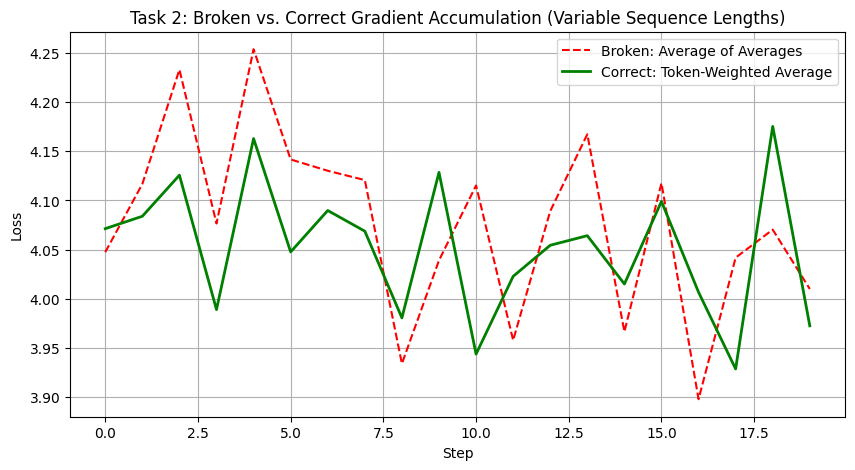

In [ ]:

import matplotlib.pyplot as plt

torch.manual_seed(42)

# Simple model setup
d_model, vocab_size = 16, 50
model = nn.Sequential(
    nn.Embedding(vocab_size, d_model),
    nn.Linear(d_model, vocab_size)
)
criterion = nn.CrossEntropyLoss(reduction='mean')

# Store loss history for plotting
broken_loss_history = []
correct_loss_history = []

# Simulate 20 training steps
for step in range(20):
    # Simulate 2 micro-batches with DIFFERENT sequence lengths
    # Micro-batch A: short sequence (e.g., 4 tokens)
    # Micro-batch B: long sequence (e.g., 32 tokens)
    x_A = torch.randint(0, vocab_size, (2, 4))
    y_A = torch.randint(0, vocab_size, (2, 4))

    x_B = torch.randint(0, vocab_size, (2, 32))
    y_B = torch.randint(0, vocab_size, (2, 32))

    # Forward pass A
    loss_A = criterion(model(x_A).view(-1, vocab_size), y_A.view(-1))
    tokens_A = y_A.numel()  # 2 * 4 = 8 tokens

    # Forward pass B
    loss_B = criterion(model(x_B).view(-1, vocab_size), y_B.view(-1))
    tokens_B = y_B.numel()  # 2 * 32 = 64 tokens

    # --- 1. BROKEN METHOD: Average of Averages (Unweighted) ---
    # Treats the 8-token batch and 64-token batch as equally important
    broken_step_loss = (loss_A.item() + loss_B.item()) / 2.0
    broken_loss_history.append(broken_step_loss)

    # --- 2. CORRECT METHOD: Token-Weighted Loss ---
    # Scales each micro-batch loss by its token count relative to total tokens
    total_tokens = tokens_A + tokens_B
    correct_step_loss = (loss_A.item() * tokens_A + loss_B.item() * tokens_B) / total_tokens
    correct_loss_history.append(correct_step_loss)

# --- PLOT THE DIVERGENCE GAP ---
plt.figure(figsize=(10, 5))
plt.plot(broken_loss_history, label='Broken: Average of Averages', color='red', linestyle='--')
plt.plot(correct_loss_history, label='Correct: Token-Weighted Average', color='green', linewidth=2)
plt.title("Task 2: Broken vs. Correct Gradient Accumulation (Variable Sequence Lengths)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Step  1 | Loss: 4.0291 (Δ 0.0693) | Grad Norm: 0.5083 (Δ 0.0186)
Step  2 | Loss: 4.1350 (Δ 0.1059) | Grad Norm: 0.5620 (Δ 0.0537)
Step  3 | Loss: 4.0618 (Δ 0.0733) | Grad Norm: 0.5278 (Δ 0.0343)
Step  4 | Loss: 3.9674 (Δ 0.0943) | Grad Norm: 0.5072 (Δ 0.0205)
Step  5 | Loss: 4.1248 (Δ 0.1574) | Grad Norm: 0.5542 (Δ 0.0470)
Step  6 | Loss: 4.0674 (Δ 0.0575) | Grad Norm: 0.5197 (Δ 0.0346)
Step  7 | Loss: 4.0234 (Δ 0.0440) | Grad Norm: 0.5087 (Δ 0.0110)
Step  8 | Loss: 4.0538 (Δ 0.0304) | Grad Norm: 0.5228 (Δ 0.0142)
Step  9 | Loss: 4.0346 (Δ 0.0192) | Grad Norm: 0.5661 (Δ 0.0433)
Step 10 | Loss: 4.1568 (Δ 0.1222) | Grad Norm: 0.5191 (Δ 0.0471)
Step 11 | Loss: 4.1464 (Δ 0.0104) | Grad Norm: 0.5218 (Δ 0.0027)
Step 12 | Loss: 4.1584 (Δ 0.0119) | Grad Norm: 0.5427 (Δ 0.0210)
Step 13 | Loss: 4.1712 (Δ 0.0128) | Grad Norm: 0.5350 (Δ 0.0078)
Step 14 | Loss: 3.9462 (Δ 0.2250) | Grad Norm: 0.4970 (Δ 0.0380)
Step 15 | Loss: 4.0789 (Δ 0.1327) | Grad Norm: 0.5177 (Δ 0.0208)
Step 16 | Loss: 4.0538 (Δ

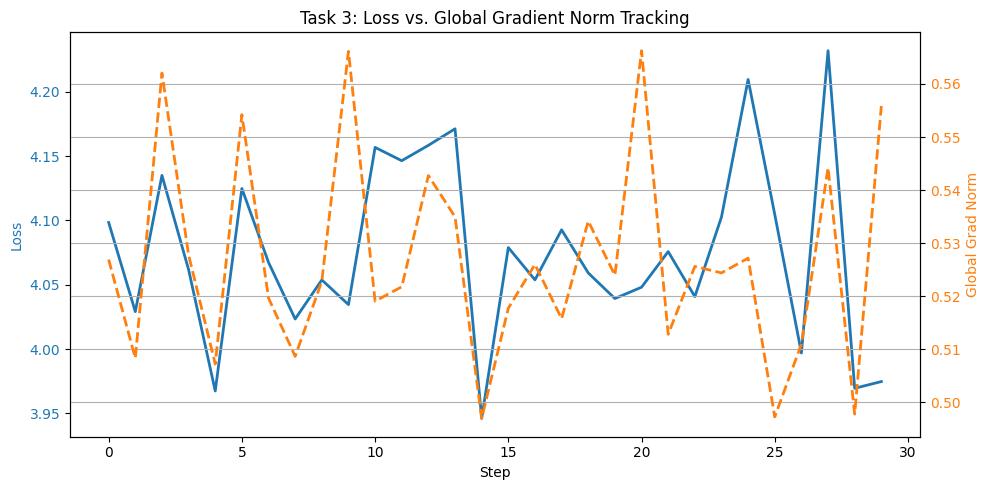

In [ ]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Small model setup
d_model, vocab_size = 16, 50
model = nn.Sequential(
    nn.Embedding(vocab_size, d_model),
    nn.Linear(d_model, vocab_size)
)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

loss_history = []
grad_norm_history = []

# Train for 30 steps and log loss + grad norm
for step in range(30):
    x = torch.randint(0, vocab_size, (4, 16))
    y = torch.randint(0, vocab_size, (4, 16))

    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits.view(-1, vocab_size), y.view(-1))
    loss.backward()

    # Calculate global gradient norm across all trainable parameters
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5

    # Log values
    loss_history.append(loss.item())
    grad_norm_history.append(total_norm)

    optimizer.step()

# --- Find Step Where Grad Norm Moved Before Loss ---
for i in range(1, len(loss_history)):
    loss_change = abs(loss_history[i] - loss_history[i-1])
    grad_change = abs(grad_norm_history[i] - grad_norm_history[i-1])
    print(f"Step {i:2d} | Loss: {loss_history[i]:.4f} (Δ {loss_change:.4f}) | Grad Norm: {grad_norm_history[i]:.4f} (Δ {grad_change:.4f})")

# --- PLOT LOSS VS GRAD NORM ---
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss', color=color)
ax1.plot(loss_history, color=color, label='Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Global Grad Norm', color=color)
ax2.plot(grad_norm_history, color=color, linestyle='--', label='Grad Norm', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Task 3: Loss vs. Global Gradient Norm Tracking")
fig.tight_layout()
plt.grid(True)
plt.show()

In [ ]:

import time

# --- 1. Model & Data Hyperparameters ---
batch_size = 8
seq_len = 128
d_model = 256
nhead = 8
num_layers = 4
vocab_size = 1000

# Theoretical GPU Peak Performance (Example: NVIDIA T4 Tensor Core FP16/BF16 peak is ~65 TFLOPS)
# Adjust PEAK_TFLOPS based on your target GPU (e.g., A100 = 312 TFLOPS, RTX 3090 = 142 TFLOPS)
PEAK_GPU_TFLOPS = 65.0

# Define Model Architecture
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return self.lm_head(self.transformer(self.embed(x)))

model = TransformerModel()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# Calculate total non-embedding parameter count (N)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- 2. Benchmark Training Loop Execution Time ---
x = torch.randint(0, vocab_size, (batch_size, seq_len))
y = torch.randint(0, vocab_size, (batch_size, seq_len))

# Warmup pass
for _ in range(3):
    optimizer.zero_grad()
    loss = criterion(model(x).view(-1, vocab_size), y.view(-1))
    loss.backward()
    optimizer.step()

# Timed execution
num_bench_steps = 20
start_time = time.perf_counter()

for _ in range(num_bench_steps):
    optimizer.zero_grad()
    loss = criterion(model(x).view(-1, vocab_size), y.view(-1))
    loss.backward()
    optimizer.step()

end_time = time.perf_counter()
total_time = end_time - start_time
avg_step_time = total_time / num_bench_steps

# --- 3. Compute MFU ---
tokens_per_step = batch_size * seq_len
head_dim = d_model // nhead

# FLOPs per step calculation
flops_per_token = (6 * num_params) + (12 * num_layers * nhead * head_dim * seq_len)
total_flops_per_step = flops_per_token * tokens_per_step

achieved_tflops = (total_flops_per_step / avg_step_time) / 1e12
mfu_percentage = (achieved_tflops / PEAK_GPU_TFLOPS) * 100

print(f"Non-Embedding Parameters (N): {num_params:,}")
print(f"Tokens per step:             {tokens_per_step}")
print(f"Average Step Time:           {avg_step_time * 1000:.2f} ms")
print(f"Achieved Compute Performance: {achieved_tflops:.4f} TFLOPS")
print(f"Theoretical Peak Capacity:    {PEAK_GPU_TFLOPS} TFLOPS")
print(f"Model FLOPs Utilization (MFU): {mfu_percentage:.2f}%")

Non-Embedding Parameters (N): 3,672,040
Tokens per step:             1024
Average Step Time:           748.07 ms
Achieved Compute Performance: 0.0323 TFLOPS
Theoretical Peak Capacity:    65.0 TFLOPS
Model FLOPs Utilization (MFU): 0.05%
